In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("cmc.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data.columns=["id","w_age","w_edu","h_edu","no_child","w_religion","w_work","h_occ","s_o_l","media_ex", "Class"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1472 entries, 2 to 1473
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   w_age       1472 non-null   int64
 1   w_edu       1472 non-null   int64
 2   h_edu       1472 non-null   int64
 3   no_child    1472 non-null   int64
 4   w_religion  1472 non-null   int64
 5   w_work      1472 non-null   int64
 6   h_occ       1472 non-null   int64
 7   s_o_l       1472 non-null   int64
 8   media_ex    1472 non-null   int64
 9   Class       1472 non-null   int64
dtypes: int64(10)
memory usage: 126.5 KB


In [7]:
data

,w_age,w_edu,h_edu,no_child,w_religion,w_work,h_occ,s_o_l,media_ex,Class
id,,,,,,,,,,
2,45,1,3,10,1,1,3,4,0,1
3,43,2,3,7,1,1,3,4,0,1
4,42,3,2,9,1,1,3,3,0,1
5,36,3,3,8,1,1,3,2,0,1
6,19,4,4,0,1,1,3,3,0,1
...,...,...,...,...,...,...,...,...,...,...
1469,33,4,4,2,1,0,2,4,0,3
1470,33,4,4,3,1,1,1,4,0,3
1471,39,3,3,8,1,0,1,4,0,3


In [8]:
gb=data.groupby("Class")

In [9]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
      w_age  w_edu  h_edu  no_child  w_religion  w_work  h_occ  s_o_l  \
id                                                                      
2        45      1      3        10           1       1      3      4   
3        43      2      3         7           1       1      3      4   
4        42      3      2         9           1       1      3      3   
5        36      3      3         8           1       1      3      2   
6        19      4      4         0           1       1      3      3   
...     ...    ...    ...       ...         ...     ...    ...    ...   
1210     46      4      4         6           1       1      1      4   
1211     33      3      3         3           1       1      3      4   
1212     49      1      2         5           1       0      2      2   
1213     21      2      4         3           1       1      3      2   
1214     31      4      4         0           0       0      2      4   

      media_ex  Class  
id                     


In [10]:
gb.get_group(1)

,w_age,w_edu,h_edu,no_child,w_religion,w_work,h_occ,s_o_l,media_ex,Class
id,,,,,,,,,,
2,45,1,3,10,1,1,3,4,0,1
3,43,2,3,7,1,1,3,4,0,1
4,42,3,2,9,1,1,3,3,0,1
5,36,3,3,8,1,1,3,2,0,1
6,19,4,4,0,1,1,3,3,0,1
...,...,...,...,...,...,...,...,...,...,...
1210,46,4,4,6,1,1,1,4,0,1
1211,33,3,3,3,1,1,3,4,0,1
1212,49,1,2,5,1,0,2,2,1,1


In [11]:
class_samples=gb.get_group(1).sample(n=25)
#    print(class_samples)

In [12]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [13]:
mean_sum=class_samples["w_age"].mean() + class_samples["w_edu"].mean() + class_samples["h_edu"].mean() + class_samples["no_child"].mean() + class_samples["w_religion"].mean() + class_samples["w_work"].mean() + class_samples["h_occ"].mean() + class_samples["s_o_l"].mean() + class_samples["media_ex"].mean()

In [14]:
column_length=len(data.columns) -1

In [15]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

4.928888888888888


In [16]:
class_2_samples=gb.get_group(2).sample(n=25)
#    print(class_2_samples)

In [17]:
mean_sum_2=class_2_samples["w_age"].mean() + class_2_samples["w_edu"].mean() + class_2_samples["h_edu"].mean() + class_2_samples["no_child"].mean() + class_2_samples["w_religion"].mean() + class_2_samples["w_work"].mean() + class_2_samples["h_occ"].mean() + class_2_samples["s_o_l"].mean() + class_2_samples["media_ex"].mean()


In [18]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

5.942222222222222


In [19]:
class_3_samples=gb.get_group(3).sample(n=25)
#    print(class_3_samples)

In [20]:
mean_sum_3=class_3_samples["w_age"].mean() + class_3_samples["w_edu"].mean() + class_3_samples["h_edu"].mean() + class_3_samples["no_child"].mean() + class_3_samples["w_religion"].mean() + class_3_samples["w_work"].mean() + class_3_samples["h_occ"].mean() + class_3_samples["s_o_l"].mean() + class_3_samples["media_ex"].mean()

In [21]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

5.111111111111112


In [22]:
sim_23=similar_val_3 - similar_val_2
sim_23=sim_23/100
sim_23=1 - sim_23
sim_12=similar_val_1 - similar_val_2
sim_12=sim_12/100
sim_12=1 - sim_12
sim_13=similar_val_3 - similar_val_1
sim_13=sim_13/100
sim_13=1 - sim_13

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 1: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)

Similarity between 2 and 3:  1.0083111111111112
Similarity between 2 and 1:  1.0101333333333333
Similarity between 1 and 3:  0.9981777777777777


In [23]:
gb.size()

Class
1    628
2    333
3    511
dtype: int64

In [24]:
m=math.ceil((628+333)/2)

In [25]:
print(m)

481


In [26]:
len(gb)

3

In [27]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [28]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [29]:
result=neigh.kneighbors(data, return_distance=True)

In [30]:
print(type(result))

<class 'tuple'>


In [31]:
print(result)

(array([[0.        , 2.        , 2.23606798, 2.82842712, 2.82842712],
       [0.        , 1.41421356, 1.73205081, 1.73205081, 2.        ],
       [0.        , 1.41421356, 1.73205081, 2.44948974, 2.44948974],
       ...,
       [0.        , 2.64575131, 2.64575131, 2.82842712, 2.82842712],
       [0.        , 1.        , 1.41421356, 1.73205081, 1.73205081],
       [0.        , 1.73205081, 1.73205081, 2.        , 2.23606798]]), array([[   0, 1062, 1222, 1086,  378],
       [   1,  423,  279,  256,   28],
       [   2,   59,  340,   65, 1000],
       ...,
       [1469,  466,  850,  957, 1244],
       [1470, 1373,  844, 1376, 1424],
       [1471,  589, 1327,  430, 1393]], dtype=int64))


In [32]:
arr1=result[0]

In [33]:
print(type(arr1))

<class 'numpy.ndarray'>


In [34]:
print(arr1.ndim)

2


In [35]:
arr2=result[1]

In [36]:
print(type(arr2))

<class 'numpy.ndarray'>


In [37]:
print(arr1.ndim)

2


In [38]:
print(arr2)

[[   0 1062 1222 1086  378]
 [   1  423  279  256   28]
 [   2   59  340   65 1000]
 ...
 [1469  466  850  957 1244]
 [1470 1373  844 1376 1424]
 [1471  589 1327  430 1393]]


In [39]:
print(arr1)

[[0.         2.         2.23606798 2.82842712 2.82842712]
 [0.         1.41421356 1.73205081 1.73205081 2.        ]
 [0.         1.41421356 1.73205081 2.44948974 2.44948974]
 ...
 [0.         2.64575131 2.64575131 2.82842712 2.82842712]
 [0.         1.         1.41421356 1.73205081 1.73205081]
 [0.         1.73205081 1.73205081 2.         2.23606798]]


In [40]:
#print(arr1)

In [41]:
print(arr1.size)

7360


In [42]:
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         2.         2.23606798 2.82842712 2.82842712]   9  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         1.41421356 1.73205081 2.44948974 2.44948974]   8  
[0.         1.41421356 2.         2.         2.23606798]   7  
[0.         1.41421356 1.41421356 1.41421356 1.73205081]   5  
[0.         1.73205081 1.73205081 1.73205081 1.73205081]   6  
[0.         1.73205081 1.73205081 1.73205081 1.73205081]   6  
[0.         1.         1.41421356 1.41421356 1.73205081]   5  
[0.         2.         2.23606798 2.23606798 2.23606798]   8  
[0.         2.         2.23606798 2.23606798 2.23606798]   8  
[0.         2.         2.23606798 2.23606798 2.44948974]   8  
[0.         1.         1.41421356 1.41421356 1.73205081]   5  
[0.         1.73205081 1.73205081 1.73205081 2.44948974]   7  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         1.         1.73205081 2.         2.23606798]   6  
[0.         1.73205081 1.73205081 2.         2.23606798

[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.73205081 1.73205081 1.73205081 1.73205081]   6  
[0.         1.73205081 2.         2.23606798 2.44948974]   8  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.73205081 2.         2.         2.        ]   7  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         1.         1.41421356 1.73205081 1.73205081]   5  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.         1.         1.         1.41421356]   4  
[0.         1.73205081 1.73205081 1.73205081 2.        ]   7  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.73205081 2.64575131 2.64575131 2.64575131

[0.         1.73205081 1.73205081 1.73205081 2.        ]   7  
[0.         1.         1.41421356 1.41421356 1.73205081]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.73205081 1.73205081 1.73205081 2.        ]   7  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         2.23606798 2.23606798 2.23606798 2.23606798]   8  
[0.         1.         1.41421356 1.73205081 2.        ]   6  
[0.         2.23606798 2.44948974 2.44948974 2.44948974]   9  
[0.         2.         2.         2.         2.23606798]   8  
[0.         2.         2.         2.23606798 2.23606798]   8  
[0.         2.23606798 2.23606798 2.44948974 2.44948974]   9  
[0.         1.41421356 2.         2.         2.23606798]   7  
[0.         2.         2.         2.         2.23606798]   8  
[0.         1.         1.41421356 1.73205081 1.73205081]   5  
[0.         2.64575131 2.64575131 2.82842712 3.        ]   11  
[0.         1.41421356 1.73205081 1.73205081 1.7320508

[0. 0. 1. 1. 1.]   3  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0. 0. 0. 1. 1.]   2  
[0.         1.         1.         1.         1.41421356]   4  
[0.         0.         1.         1.         1.41421356]   3  
[0.         1.41421356 1.73205081 2.         2.        ]   7  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.         1.41421356 1.41421356]   4  
[0. 0. 0. 1. 1.]   2  
[0. 0. 1. 1. 1.]   3  
[0.         1.         1. 

[0.         1.41421356 2.         2.         2.        ]   7  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.         1.41421356 1.41421356 1.73205081]   5  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 2.         2.         2.        ]   7  
[0.         1.         1.73205081 1.73205081 2.23606798]   6  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.73205081 2.23606798 2.23606798 2.44948974]   8  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         0.         1.         1.41421356 1.41421356]   3  
[0.         0.         1.         1.41421356 1.41421356]   3  
[0.         0.         1.         1.41421356 1.41421356

[0.         1.41421356 1.73205081 2.         2.        ]   7  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.73205081 1.73205081 1.73205081 1.73205081]   6  
[0.         0.         1.         1.41421356 1.41421356]   3  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         2.23606798 2.44948974 2.44948974 2.64575131]   9  
[0.         1.         1.73205081 1.73205081 2.        ]   6  
[0.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.41421356 2.23606798 2.23606798 2.44948974]   8  
[0.         1.41421356 1.73205081 2.         2.        ]   7  
[0.         2.23606798 2.23606798 2.44948974 2.64575131]   9  
[0.         2.         2.44948974 2.82842712 2.82842712]   10  
[0. 0. 1. 1. 1.]   3  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.         1.      

[0.         1.41421356 1.73205081 1.73205081 2.23606798]   7  
[0.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.73205081 2.         2.44948974 2.44948974]   8  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.         1.41421356 1.73205081]   5  
[0.         1.         1.73205081 1.73205081 2.        ]   6  
[0.         1.41421356 1.41421356 1.41421356 2.        ]   6  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.73205081 1.73205081 2.23606798 2.23606798]   7  
[0.         2.         2.         2.         2.23606798]   8  
[0.         2.44948974 2.64575131 2.82842712 2.82842712]   10  
[0.         1.73205081 1.73205081 2.23606798 2.23606798]   7  
[0.         1.73205081 2.         2.         2.        ]   7  
[0.         2.23606798 2.23606798 2.64575131 2.6457513

[0.         1.73205081 2.23606798 2.23606798 2.44948974]   8  
[0.         0.         0.         1.         1.41421356]   2  
[0.         2.44948974 2.44948974 2.82842712 3.16227766]   10  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.41421356 1.41421356 1.73205081 1.73205081]   6  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         2.         2.23606798 2.23606798 2.23606798]   8  
[0.         1.41421356 1.41421356 1.41421356 1.73205081]   5  
[0.         1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.41421356 1.41421356 1.73205081]   5  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         0.         1.41421356 1.41421356 1.41421356]   4  
[0.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.73205081 1.73205081 1.73205081 2.        ]   7  
[0.         1.41421356 1.73205081 1.73205081 2.23606798]   7  
[0.         1.         1.         1.41421356 1.4142135

[0.         1.41421356 1.73205081 2.         2.        ]   7  
[0.         1.41421356 1.41421356 1.41421356 1.73205081]   5  
[0.         1.73205081 2.         2.         2.        ]   7  
[0.         1.73205081 1.73205081 1.73205081 1.73205081]   6  
[0.         1.73205081 2.44948974 2.44948974 2.64575131]   9  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0. 0. 1. 1. 1.]   3  
[0.         2.44948974 2.44948974 2.44948974 2.64575131]   9  
[0.         1.41421356 1.41421356 1.41421356 1.73205081]   5  
[0.         1.41421356 1.41421356 1.41421356 1.73205081]   5  
[0.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.41421356 1.41421356 1.41421356]   5  
[0.         1.41421356 1.73205081 2.         2.        ]   7  
[0.         1.41421356 1.73205081 1.73205081 2.        ]   6  
[0.         1.41421356 1.73205081 1.73205081 1.73205081]   6  
[0.         1.41421356 1.41421356 1.73205081 2.        ]   6  
[0.         1.41421356 1.7320508

In [43]:
print(len(addVal))

1472


In [44]:
print(addVal)

[9, 6, 8, 7, 5, 6, 6, 5, 8, 8, 8, 5, 7, 6, 6, 7, 8, 8, 7, 7, 7, 5, 5, 5, 8, 4, 4, 6, 8, 4, 6, 7, 8, 6, 8, 8, 7, 8, 8, 9, 9, 9, 6, 7, 6, 6, 6, 2, 5, 5, 6, 8, 6, 5, 8, 5, 7, 4, 8, 6, 5, 6, 6, 6, 6, 9, 7, 5, 5, 7, 9, 6, 6, 4, 5, 3, 5, 6, 4, 6, 5, 7, 6, 4, 4, 4, 5, 7, 7, 6, 7, 6, 9, 6, 9, 7, 9, 9, 9, 8, 7, 7, 7, 5, 7, 7, 7, 6, 6, 8, 8, 4, 7, 5, 5, 6, 5, 7, 5, 9, 5, 5, 6, 10, 8, 4, 8, 9, 6, 10, 6, 7, 7, 4, 7, 5, 6, 8, 5, 5, 7, 6, 5, 6, 4, 7, 6, 6, 4, 6, 9, 6, 5, 6, 7, 6, 7, 11, 5, 9, 4, 8, 7, 5, 6, 6, 2, 4, 6, 4, 8, 6, 5, 5, 7, 5, 7, 8, 12, 5, 5, 8, 11, 7, 7, 5, 9, 6, 8, 9, 6, 15, 5, 8, 8, 6, 7, 9, 6, 10, 6, 7, 5, 9, 5, 6, 7, 5, 7, 5, 8, 6, 8, 8, 7, 9, 8, 9, 5, 6, 4, 9, 8, 4, 6, 6, 8, 8, 5, 7, 6, 7, 4, 7, 5, 7, 5, 7, 5, 5, 7, 9, 5, 6, 5, 5, 5, 6, 11, 7, 6, 4, 4, 6, 6, 6, 7, 8, 6, 7, 9, 7, 5, 7, 5, 6, 8, 7, 9, 4, 5, 5, 8, 6, 6, 10, 9, 7, 6, 7, 6, 4, 8, 8, 7, 4, 8, 6, 10, 5, 5, 4, 6, 5, 6, 8, 5, 5, 2, 9, 8, 5, 5, 5, 5, 8, 7, 5, 5, 7, 6, 8, 6, 9, 8, 8, 9, 7, 8, 5, 11, 6, 7, 5, 5, 9, 6, 7, 5, 6

In [45]:
arr3=np.array(addVal)

In [46]:
print(type(arr3))

<class 'numpy.ndarray'>


In [47]:
print(arr3.size)

1472


In [48]:
print(arr3)

[ 9  6  8 ... 10  5  7]


In [49]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   9
2   6
3   8
4   7
5   5
6   6
7   6
8   5
9   8
10   8
11   8
12   5
13   7
14   6
15   6
16   7
17   8
18   8
19   7
20   7
21   7
22   5
23   5
24   5
25   8
26   4
27   4
28   6
29   8
30   4
31   6
32   7
33   8
34   6
35   8
36   8
37   7
38   8
39   8
40   9
41   9
42   9
43   6
44   7
45   6
46   6
47   6
48   2
49   5
50   5
51   6
52   8
53   6
54   5
55   8
56   5
57   7
58   4
59   8
60   6
61   5
62   6
63   6
64   6
65   6
66   9
67   7
68   5
69   5
70   7
71   9
72   6
73   6
74   4
75   5
76   3
77   5
78   6
79   4
80   6
81   5
82   7
83   6
84   4
85   4
86   4
87   5
88   7
89   7
90   6
91   7
92   6
93   9
94   6
95   9
96   7
97   9
98   9
99   9
100   8
101   7
102   7
103   7
104   5
105   7
106   7
107   7
108   6
109   6
110   8
111   8
112   4
113   7
114   5
115   5
116   6
117   5
118   7
119   5
120   9
121   5
122   5
123   6
124   10
125   8
126   4
127   8
128   9
129   6
130   10
131   6
132   7
133   7
134   4
135   7
136   5
137   6
138   8
13

1082   5
1083   5
1084   6
1085   8
1086   5
1087   8
1088   10
1089   9
1090   5
1091   5
1092   8
1093   5
1094   8
1095   4
1096   5
1097   10
1098   7
1099   10
1100   5
1101   5
1102   4
1103   6
1104   7
1105   5
1106   4
1107   8
1108   7
1109   4
1110   8
1111   5
1112   6
1113   5
1114   5
1115   6
1116   6
1117   6
1118   7
1119   8
1120   10
1121   7
1122   7
1123   9
1124   7
1125   8
1126   7
1127   9
1128   4
1129   5
1130   8
1131   9
1132   5
1133   5
1134   4
1135   6
1136   6
1137   7
1138   8
1139   12
1140   5
1141   6
1142   9
1143   5
1144   6
1145   4
1146   6
1147   3
1148   6
1149   8
1150   4
1151   5
1152   10
1153   5
1154   6
1155   7
1156   7
1157   8
1158   11
1159   7
1160   4
1161   9
1162   8
1163   6
1164   6
1165   5
1166   9
1167   9
1168   9
1169   8
1170   7
1171   7
1172   9
1173   8
1174   7
1175   6
1176   8
1177   8
1178   5
1179   7
1180   6
1181   7
1182   6
1183   9
1184   6
1185   7
1186   6
1187   4
1188   5
1189   8
1190   6
1191   5
119

In [50]:
newarr = arr3.reshape(1472, 1)

In [51]:
print(newarr.ndim)

2


In [52]:
new_arr2=np.append(arr2, newarr, axis=1)

In [53]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [54]:
print(new_arr2)

[[   0 1062 1222 1086  378    9]
 [   1  423  279  256   28    6]
 [   2   59  340   65 1000    8]
 ...
 [1469  466  850  957 1244   10]
 [1470 1373  844 1376 1424    5]
 [1471  589 1327  430 1393    7]]


In [55]:
print(new_arr2[0])

[   0 1062 1222 1086  378    9]


In [56]:
arr2

array([[   0, 1062, 1222, 1086,  378],
       [   1,  423,  279,  256,   28],
       [   2,   59,  340,   65, 1000],
       ...,
       [1469,  466,  850,  957, 1244],
       [1470, 1373,  844, 1376, 1424],
       [1471,  589, 1327,  430, 1393]], dtype=int64)

In [57]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

1062 1222 1086 378 9


In [58]:
# Creating and populating a dictionary
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [59]:
print(new_dist)

{2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 1, 139: 1, 1

In [60]:
# Creating and populating a dictionary
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [61]:
print(new_dist2)

{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 

In [62]:
# Creating and populating a dictionary
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [63]:
print(new_dist3)

{0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13, 12: 14, 13: 15, 14: 16, 15: 17, 16: 18, 17: 19, 18: 20, 19: 21, 20: 22, 21: 23, 22: 24, 23: 25, 24: 26, 25: 27, 26: 28, 27: 29, 28: 30, 29: 31, 30: 32, 31: 33, 32: 34, 33: 35, 34: 36, 35: 37, 36: 38, 37: 39, 38: 40, 39: 41, 40: 42, 41: 43, 42: 44, 43: 45, 44: 46, 45: 47, 46: 48, 47: 49, 48: 50, 49: 51, 50: 52, 51: 53, 52: 54, 53: 55, 54: 56, 55: 57, 56: 58, 57: 59, 58: 60, 59: 61, 60: 62, 61: 63, 62: 64, 63: 65, 64: 66, 65: 67, 66: 68, 67: 69, 68: 70, 69: 71, 70: 72, 71: 73, 72: 74, 73: 75, 74: 76, 75: 77, 76: 78, 77: 79, 78: 80, 79: 81, 80: 82, 81: 83, 82: 84, 83: 85, 84: 86, 85: 87, 86: 88, 87: 89, 88: 90, 89: 91, 90: 92, 91: 93, 92: 94, 93: 95, 94: 96, 95: 97, 96: 98, 97: 99, 98: 100, 99: 101, 100: 102, 101: 103, 102: 104, 103: 105, 104: 106, 105: 107, 106: 108, 107: 109, 108: 110, 109: 111, 110: 112, 111: 113, 112: 114, 113: 115, 114: 116, 115: 117, 116: 118, 117: 119, 118: 120, 119: 121, 120: 122, 121: 

In [64]:
#print(new_dist[204])

<!-- Populating a dictionary  -->

In [65]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        class_example=0
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        else:
            c3=c3+1
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            else:
                c3=c3+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3)/5
                class_example=2
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3)/5
                class_example=3
                safe_level=round(safe_level,2)
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,safe_level,new_arr2[i][5]])
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [66]:
#print(neigh_count)

In [67]:
# iterating a dictionary

In [68]:
# for s in range(149):
#     print(neigh_count[s])

In [69]:
# Converting a dictionary to a dataframe

In [70]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','safe_level','distance'])

In [71]:
#print(new_main_df)

In [72]:
new_main_df.set_index("s_no", inplace=True)

In [73]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
0              2      1      4      1        0         1.0         9
1              3      1      4      1        0         1.0         6
2              4      1      5      0        0         1.0         8
3              5      1      4      1        0         1.0         7
4              6      1      5      0        0         1.0         5
...          ...    ...    ...    ...      ...         ...       ...
1467        1469      3      0      0        5         1.0         4
1468        1470      3      0      2        3         1.0         4
1469        1471      3      0      2        3         1.0        10
1470        1472      3      0      0        5         1.0         5
1471        1473      3      0      2        3         1.0         7

[1472 rows x 7 columns]


In [74]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [75]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [76]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 2
1 3
2 4
3 5
4 6
5 7
6 8
7 9
8 10
9 11
10 12
11 13
12 14
13 15
14 16
15 17
16 18
17 19
18 20
19 21
20 22
21 23
22 24
23 25
24 26
25 27
26 28
27 29
28 30
29 31
30 32
31 33
32 34
33 35
34 36
35 37
36 38
37 39
38 40
39 41
40 42
41 43
42 44
43 45
44 46
45 47
46 48
47 49
48 50
49 51
50 52
51 53
52 54
53 55
54 56
55 57
56 58
57 59
58 60
59 61
60 62
61 63
62 64
63 65
64 66
65 67
66 68
67 69
68 70
69 71
70 72
71 73
72 74
73 75
74 76
75 77
76 78
77 79
78 80
79 81
80 82
81 83
82 84
83 85
84 86
85 87
86 88
87 89
88 90
89 91
90 92
91 93
92 94
93 95
94 96
95 97
96 98
97 99
98 100
99 101
100 102
101 103
102 104
103 105
104 106
105 107
106 108
107 109
108 110
109 111
110 112
111 113
112 114
113 115
114 116
115 117
116 118
117 119
118 120
119 121
120 122
121 123
122 124
123 125
124 126
125 127
126 128
127 129
128 130
129 131
130 132
131 133
132 134
133 135
134 136
135 137
136 138
137 139
138 140
139 141
140 142
141 143
142 144
143 145
144 146
145 147
146 148
147 149
148 150
149 151
150 152
151 153


1329 1331
1330 1332
1331 1333
1332 1334
1333 1335
1334 1336
1335 1337
1336 1338
1337 1339
1338 1340
1339 1341
1340 1342
1341 1343
1342 1344
1343 1345
1344 1346
1345 1347
1346 1348
1347 1349
1348 1350
1349 1351
1350 1352
1351 1353
1352 1354
1353 1355
1354 1356
1355 1357
1356 1358
1357 1359
1358 1360
1359 1361
1360 1362
1361 1363
1362 1364
1363 1365
1364 1366
1365 1367
1366 1368
1367 1369
1368 1370
1369 1371
1370 1372
1371 1373
1372 1374
1373 1375
1374 1376
1375 1377
1376 1378
1377 1379
1378 1380
1379 1381
1380 1382
1381 1383
1382 1384
1383 1385
1384 1386
1385 1387
1386 1388
1387 1389
1388 1390
1389 1391
1390 1392
1391 1393
1392 1394
1393 1395
1394 1396
1395 1397
1396 1398
1397 1399
1398 1400
1399 1401
1400 1402
1401 1403
1402 1404
1403 1405
1404 1406
1405 1407
1406 1408
1407 1409
1408 1410
1409 1411
1410 1412
1411 1413
1412 1414
1413 1415
1414 1416
1415 1417
1416 1418
1417 1419
1418 1420
1419 1421
1420 1422
1421 1423
1422 1424
1423 1425
1424 1426
1425 1427
1426 1428
1427 1429
1428 1430


In [77]:
new_classes=new_main_df.groupby("Class")

In [78]:
new_classes.size()

Class
1    628
2    333
3    511
dtype: int64

In [79]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

535 89 4 0


In [80]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_two==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

171 131 31 0


In [81]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_three==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

409 97 5 0


In [82]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [83]:
new_gb=new_main_df.groupby("Class")

In [84]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [85]:
#new_1

In [86]:
#new_2=new_gb.get_group(2)

In [87]:
#new_3=new_gb.get_group(3)

In [88]:
gb_1=gb.get_group(1)

In [89]:
gb_2=gb.get_group(2)

In [90]:
gb_3=gb.get_group(3)

In [91]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [92]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [93]:
#new_2

In [94]:
#for dropping some index with less simlar neigbour
#new_2.drop(new_2[new_2['c_two'] < 4].index, inplace=True)

In [95]:
#new_2

In [96]:
#b=len(new_2.index)

In [97]:
#print(b)

In [98]:
#s=m - b

In [99]:
#print(s)

In [100]:
#if(s>b):
    #minor_c_2=new_2.sample(n=b, replace='False')
    #print(len(minor_c_2.index))
    #minor_c_2=minor_c_2.sample(n=b, replace='True')
    #print(len(minor_c_2.index))

In [101]:
#u=len(minor_c_2.index)

In [102]:
#print(u)

In [103]:
minor_c_2=new_2.sample(n=m, replace='True')
print(minor_c_2)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
1277        1279      2      0      3        2        1.00         5
598          600      2      0      4        1        1.00         8
1263        1265      2      1      4        0        1.00         3
416          418      2      0      3        2        1.00         4
462          464      2      0      5        0        1.00         3
...          ...    ...    ...    ...      ...         ...       ...
1213        1215      2      0      5        0        1.00         7
576          578      2      1      2        2        1.01         5
1218        1220      2      0      5        0        1.00         4
496          498      2      1      2        2        1.01         6
555          557      2      1      4        0        1.00         7

[481 rows x 7 columns]


In [104]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [105]:
#for dropping some index with less simlar neigbour
new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [106]:
minor_c_3=new_3.sample(n=m, replace='False')
print(minor_c_3)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
873          875      3      0      0        5         1.0         5
996          998      3      0      0        5         1.0         6
1426        1428      3      0      1        4         1.0         6
882          884      3      0      0        5         1.0         5
862          864      3      0      0        5         1.0         6
...          ...    ...    ...    ...      ...         ...       ...
693          695      3      0      0        5         1.0         4
983          985      3      0      0        5         1.0         2
951          953      3      0      0        5         1.0         5
827          829      3      0      1        4         1.0         4
856          858      3      0      0        5         1.0         6

[481 rows x 7 columns]


In [107]:
new_gb

In [108]:
gb

In [109]:
#new_1

In [110]:
new_1.drop(new_1[new_1['c_one'] < 5].index, inplace=True)

In [111]:
#new_1

In [112]:
#for i, row in enumerate(new_1.itertuples(index=True), 0):
    #print(i, row.Index, row.real_index, row.Class, row.c_one, row.c_two, row.c_three, row.safe_level, row.distance)

In [113]:
#r=len(new_1.index)-m

In [114]:
#print(r)

In [115]:
major_c_1=new_1.sample(n=m,  replace='False')
print(major_c_1)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
25            27      1      5      0        0         1.0         4
25            27      1      5      0        0         1.0         4
351          353      1      5      0        0         1.0         6
397          399      1      5      0        0         1.0         7
318          320      1      5      0        0         1.0         8
...          ...    ...    ...    ...      ...         ...       ...
173          175      1      5      0        0         1.0         5
322          324      1      5      0        0         1.0         7
171          173      1      5      0        0         1.0         6
280          282      1      5      0        0         1.0         6
21            23      1      5      0        0         1.0         5

[481 rows x 7 columns]


In [116]:
#for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    #print(i, row.real_index)

In [117]:
#how to generate a random list from an interval
#num_list = random.sample(range(0, len(new_1.index)), r)
#print(num_list)

In [118]:
maj_c_filtered=[]
for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'w_age']
    c=gb_1.at[row.real_index, 'w_edu']
    d=gb_1.at[row.real_index, 'h_edu']
    e=gb_1.at[row.real_index, 'no_child']
    f=gb_1.at[row.real_index, 'w_religion']
    g=gb_1.at[row.real_index, 'w_work']
    h=gb_1.at[row.real_index, 'h_occ']
    i=gb_1.at[row.real_index, 's_o_l']
    j=gb_1.at[row.real_index, 'media_ex']
    maj_c_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [119]:
print(maj_c_filtered)

[[1, 38, 4, 4, 1, 1, 0, 1, 4, 0], [1, 38, 4, 4, 1, 1, 0, 1, 4, 0], [1, 24, 2, 2, 2, 1, 1, 3, 1, 1], [1, 19, 2, 2, 0, 1, 1, 2, 2, 0], [1, 32, 2, 3, 4, 0, 1, 2, 4, 0], [1, 48, 2, 1, 3, 1, 0, 4, 3, 0], [1, 34, 2, 3, 7, 1, 0, 3, 3, 0], [1, 47, 1, 2, 7, 1, 0, 3, 2, 0], [1, 28, 1, 1, 3, 1, 1, 3, 1, 0], [1, 37, 2, 3, 4, 1, 1, 2, 3, 0], [1, 47, 4, 4, 1, 1, 0, 1, 3, 0], [1, 46, 1, 4, 8, 1, 1, 1, 4, 1], [1, 24, 2, 3, 2, 1, 1, 3, 1, 0], [1, 26, 1, 3, 1, 1, 1, 3, 1, 0], [1, 30, 4, 4, 0, 1, 0, 1, 4, 0], [1, 39, 2, 2, 6, 1, 1, 2, 4, 0], [1, 45, 4, 4, 1, 1, 0, 3, 3, 0], [1, 47, 2, 3, 0, 1, 0, 1, 3, 0], [1, 36, 2, 2, 0, 0, 0, 3, 3, 0], [1, 33, 1, 2, 0, 1, 0, 3, 3, 0], [1, 25, 3, 3, 0, 1, 1, 3, 4, 0], [1, 25, 4, 4, 0, 0, 1, 2, 4, 0], [1, 27, 1, 2, 4, 1, 1, 3, 1, 1], [1, 45, 2, 2, 7, 1, 1, 3, 1, 1], [1, 47, 1, 4, 6, 1, 1, 1, 4, 0], [1, 27, 3, 4, 0, 1, 1, 3, 3, 0], [1, 46, 3, 1, 5, 1, 1, 3, 2, 0], [1, 22, 3, 3, 2, 1, 1, 2, 4, 0], [1, 45, 1, 2, 1, 1, 0, 3, 3, 0], [1, 42, 3, 2, 1, 1, 1, 3, 3, 0], [1, 21, 2

In [120]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [121]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'w_age']
    c=gb_2.at[row.real_index, 'w_edu']
    d=gb_2.at[row.real_index, 'h_edu']
    e=gb_2.at[row.real_index, 'no_child']
    f=gb_2.at[row.real_index, 'w_religion']
    g=gb_2.at[row.real_index, 'w_work']
    h=gb_2.at[row.real_index, 'h_occ']
    i=gb_2.at[row.real_index, 's_o_l']
    j=gb_2.at[row.real_index, 'media_ex']
    min_c_2_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [122]:
print(min_c_2_filtered)

[[2, 32, 4, 4, 2, 1, 0, 3, 4, 0], [2, 35, 2, 4, 3, 0, 0, 3, 4, 1], [2, 37, 4, 4, 4, 1, 1, 1, 4, 0], [2, 35, 4, 4, 4, 1, 1, 1, 4, 0], [2, 37, 4, 4, 3, 1, 1, 1, 4, 0], [2, 33, 2, 2, 3, 1, 1, 2, 3, 0], [2, 45, 4, 4, 4, 1, 1, 1, 4, 0], [2, 27, 4, 4, 2, 1, 1, 1, 3, 0], [2, 29, 4, 4, 1, 1, 0, 2, 4, 0], [2, 27, 4, 4, 1, 1, 0, 3, 3, 0], [2, 41, 4, 4, 5, 0, 1, 2, 4, 0], [2, 46, 4, 4, 2, 1, 0, 1, 4, 0], [2, 21, 3, 4, 3, 1, 1, 1, 4, 0], [2, 31, 4, 2, 2, 0, 1, 1, 3, 0], [2, 30, 4, 4, 3, 1, 1, 2, 1, 0], [2, 45, 3, 3, 8, 1, 1, 2, 3, 0], [2, 39, 3, 4, 5, 1, 1, 3, 4, 0], [2, 44, 4, 4, 4, 1, 0, 2, 3, 0], [2, 37, 4, 4, 3, 1, 1, 1, 4, 0], [2, 31, 2, 2, 4, 1, 1, 4, 3, 1], [2, 35, 4, 4, 3, 0, 0, 3, 4, 0], [2, 45, 3, 3, 7, 1, 1, 3, 4, 0], [2, 29, 3, 4, 3, 1, 1, 1, 3, 0], [2, 35, 1, 3, 7, 1, 0, 2, 3, 1], [2, 37, 4, 4, 3, 1, 1, 1, 4, 0], [2, 45, 4, 4, 3, 0, 1, 2, 4, 0], [2, 37, 4, 4, 3, 0, 1, 3, 4, 0], [2, 44, 1, 4, 2, 1, 1, 1, 3, 0], [2, 26, 2, 4, 2, 1, 1, 1, 4, 0], [2, 37, 4, 4, 2, 1, 0, 3, 3, 0], [2, 44, 4

In [123]:
#for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    #print(i, row.real_index)

In [124]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'w_age']
    c=gb_3.at[row.real_index, 'w_edu']
    d=gb_3.at[row.real_index, 'h_edu']
    e=gb_3.at[row.real_index, 'no_child']
    f=gb_3.at[row.real_index, 'w_religion']
    g=gb_3.at[row.real_index, 'w_work']
    h=gb_3.at[row.real_index, 'h_occ']
    i=gb_3.at[row.real_index, 's_o_l']
    j=gb_3.at[row.real_index, 'media_ex']
    min_c_3_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [125]:
print(min_c_3_filtered)

[[3, 24, 4, 3, 3, 1, 1, 3, 3, 0], [3, 28, 2, 3, 6, 1, 1, 2, 4, 0], [3, 31, 4, 4, 4, 1, 0, 3, 4, 0], [3, 28, 3, 3, 4, 1, 1, 3, 3, 0], [3, 20, 4, 3, 1, 1, 1, 3, 4, 0], [3, 21, 3, 3, 1, 1, 1, 3, 2, 0], [3, 26, 2, 4, 3, 1, 1, 3, 4, 0], [3, 32, 3, 4, 4, 1, 1, 3, 2, 0], [3, 31, 1, 1, 3, 1, 1, 4, 2, 1], [3, 20, 4, 3, 1, 1, 1, 3, 4, 0], [3, 35, 2, 3, 6, 1, 0, 3, 3, 0], [3, 36, 4, 4, 6, 0, 1, 1, 2, 1], [3, 35, 1, 2, 5, 1, 1, 3, 3, 0], [3, 31, 4, 4, 3, 1, 1, 1, 4, 0], [3, 22, 4, 4, 1, 1, 1, 2, 3, 0], [3, 34, 4, 4, 2, 0, 1, 1, 4, 0], [3, 26, 2, 3, 2, 1, 1, 2, 3, 0], [3, 29, 3, 3, 4, 1, 1, 3, 4, 0], [3, 28, 4, 4, 2, 1, 1, 1, 4, 0], [3, 28, 4, 4, 1, 1, 1, 3, 2, 0], [3, 25, 2, 3, 5, 1, 1, 2, 3, 0], [3, 28, 1, 3, 5, 1, 1, 3, 4, 0], [3, 32, 4, 4, 3, 1, 0, 1, 4, 0], [3, 25, 4, 4, 2, 1, 1, 2, 4, 0], [3, 26, 4, 4, 1, 1, 0, 2, 4, 0], [3, 22, 2, 2, 2, 1, 1, 2, 3, 0], [3, 29, 3, 3, 6, 1, 1, 3, 3, 0], [3, 41, 1, 2, 6, 1, 1, 3, 3, 0], [3, 27, 2, 4, 4, 1, 1, 2, 1, 0], [3, 25, 4, 4, 1, 0, 1, 1, 4, 0], [3, 24, 2

In [126]:
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered,columns=['Class','w_age','w_edu','h_edu','no_child','w_religion','w_work','h_occ','s_o_l','media_ex'])

In [127]:
print(new_min_c_3_filtered)

     Class  w_age  w_edu  h_edu  no_child  w_religion  w_work  h_occ  s_o_l  \
0        3     24      4      3         3           1       1      3      3   
1        3     28      2      3         6           1       1      2      4   
2        3     31      4      4         4           1       0      3      4   
3        3     28      3      3         4           1       1      3      3   
4        3     20      4      3         1           1       1      3      4   
..     ...    ...    ...    ...       ...         ...     ...    ...    ...   
476      3     26      2      4         3           1       1      3      4   
477      3     32      4      4         3           1       0      1      4   
478      3     26      3      4         4           1       1      2      4   
479      3     35      4      4         3           1       1      1      4   
480      3     27      4      4         1           0       1      3      4   

     media_ex  
0           0  
1           0  
2  

In [128]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered,columns=['Class','w_age','w_edu','h_edu','no_child','w_religion','w_work','h_occ','s_o_l','media_ex'])

In [129]:
print(new_min_c_2_filtered)

     Class  w_age  w_edu  h_edu  no_child  w_religion  w_work  h_occ  s_o_l  \
0        2     32      4      4         2           1       0      3      4   
1        2     35      2      4         3           0       0      3      4   
2        2     37      4      4         4           1       1      1      4   
3        2     35      4      4         4           1       1      1      4   
4        2     37      4      4         3           1       1      1      4   
..     ...    ...    ...    ...       ...         ...     ...    ...    ...   
476      2     42      4      4         4           1       1      3      4   
477      2     43      4      4         3           0       1      1      4   
478      2     21      4      4         1           1       1      1      3   
479      2     26      4      4         1           0       1      2      4   
480      2     32      3      3         6           1       0      3      3   

     media_ex  
0           0  
1           1  
2  

In [130]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','w_age','w_edu','h_edu','no_child','w_religion','w_work','h_occ','s_o_l','media_ex'])

In [131]:
print(new_maj_c_filtered)

     Class  w_age  w_edu  h_edu  no_child  w_religion  w_work  h_occ  s_o_l  \
0        1     38      4      4         1           1       0      1      4   
1        1     38      4      4         1           1       0      1      4   
2        1     24      2      2         2           1       1      3      1   
3        1     19      2      2         0           1       1      2      2   
4        1     32      2      3         4           0       1      2      4   
..     ...    ...    ...    ...       ...         ...     ...    ...    ...   
476      1     25      3      2         2           1       1      3      2   
477      1     21      1      3         0           1       0      3      4   
478      1     22      2      4         1           1       1      2      4   
479      1     21      2      4         2           1       1      3      1   
480      1     46      4      4         1           0       1      1      4   

     media_ex  
0           0  
1           0  
2  

In [132]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered], ignore_index='True')

In [133]:
print(result)

      Class  w_age  w_edu  h_edu  no_child  w_religion  w_work  h_occ  s_o_l  \
0         1     38      4      4         1           1       0      1      4   
1         1     38      4      4         1           1       0      1      4   
2         1     24      2      2         2           1       1      3      1   
3         1     19      2      2         0           1       1      2      2   
4         1     32      2      3         4           0       1      2      4   
...     ...    ...    ...    ...       ...         ...     ...    ...    ...   
1438      3     26      2      4         3           1       1      3      4   
1439      3     32      4      4         3           1       0      1      4   
1440      3     26      3      4         4           1       1      2      4   
1441      3     35      4      4         3           1       1      1      4   
1442      3     27      4      4         1           0       1      3      4   

      media_ex  
0            0  
1    

In [134]:
result.to_csv("balanced_cmc.csv")

In [135]:
result=result.sample(frac=1).reset_index(drop=True)

In [136]:
result.to_csv("balanced_cmc_rand.csv")

In [137]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [138]:
categories=result.groupby("Class")

In [139]:
w=categories.size()

In [140]:
print(w)

Class
1    481
2    481
3    481
dtype: int64


In [141]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [142]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [143]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [144]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [145]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.792147806004619
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.8799076212471132


In [146]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [147]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.8418553903643627
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9089689249018398


In [148]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [149]:
cm_model_test

array([[129,   8,   0],
       [ 16,  98,  41],
       [  0,  25, 116]], dtype=int64)

In [150]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

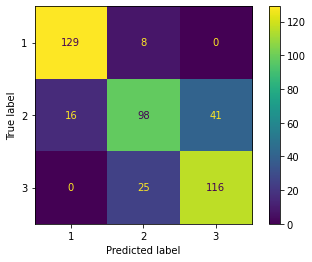

In [151]:
disp_model.plot() 

In [152]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [153]:
cm_clf_test

array([[137,   0,   0],
       [  0, 155,   0],
       [  0,   0, 141]], dtype=int64)

In [154]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

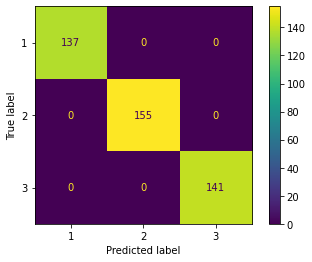

In [155]:
disp_clf.plot() 

In [156]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [157]:
cm_knn_test

array([[133,   3,   1],
       [ 10, 128,  17],
       [  3,  18, 120]], dtype=int64)

In [158]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

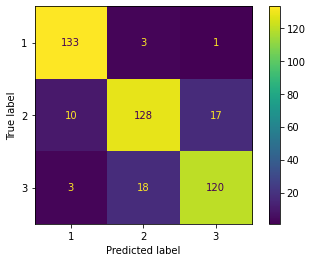

In [159]:
disp_knn.plot()

In [160]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       137
           2      1.000     1.000     1.000       155
           3      1.000     1.000     1.000       141

    accuracy                          1.000       433
   macro avg      1.000     1.000     1.000       433
weighted avg      1.000     1.000     1.000       433



In [161]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.911     0.971     0.940       137
           2      0.859     0.826     0.842       155
           3      0.870     0.851     0.860       141

    accuracy                          0.880       433
   macro avg      0.880     0.883     0.881       433
weighted avg      0.879     0.880     0.879       433



In [162]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.890     0.942     0.915       137
           2      0.748     0.632     0.685       155
           3      0.739     0.823     0.779       141

    accuracy                          0.792       433
   macro avg      0.792     0.799     0.793       433
weighted avg      0.790     0.792     0.788       433



In [163]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [164]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')